### Sturcture Modify 代码测试
可以单使用，链式使用结构修改  
可以获取原始结构，修改后的结构内容  

In [14]:
import sys
from pathlib import Path
from pymatgen.core import Structure

# 注意：这里去掉了最后的 /vasp_catalysis_tools
actual_path = "/data2/home/luodh/Git-workflow/Workflow_for_vasp_catalysis"

if actual_path not in sys.path:
    sys.path.insert(0, actual_path)

print("Current sys.path:", sys.path[0])

# 现在 Python 会在 actual_path 下面找到 vasp_catalysis_tools 文件夹了
from vasp_catalysis_tools.core.structure_modify import StructureModify
output_path = Path("/data2/home/luodh/Test/VaspStructure-Test/").resolve()

Current sys.path: /data2/home/luodh/Git-workflow/Workflow_for_vasp_catalysis


In [15]:


sture = Structure.from_file("/data2/home/luodh/Test/VaspStructure-Test/POSCAR")
modifier = StructureModify(sture)
##单使用-supercell
sture2 = modifier.make_supercell("2x2x2").get_structure()
sture2.to(output_path / "supercell-POSCAR", fmt="poscar")
##单使用-insert
strure3 = modifier.reset_to_initial().insert_atom("Pd", [0,0,0]).get_structure()
strure3.to(output_path / "insert-POSCAR", fmt="POSCAR")
##单使用-修改元素
strure4 = modifier.reset_to_initial().replace_species_all({"Al":"Cu"}).get_structure()
strure4.to(output_path / "replace-POSCAR", fmt="POSCAR")
##单使用-精准原子操作
strure5 = modifier.reset_to_initial().modify_atom_element(index=0, new_element="Cu").get_structure()
strure5.to(output_path / "replace-single-POSCAR", fmt="POSCAR")
##原子位置移动使用
sture6 = modifier.reset_to_initial().modify_atom_coords(index=0, coords=[0, 0, 0.1], frac_coords=True).get_structure()
sture6.to(output_path / "move-POSCAR", fmt="POSCAR")
##多原子位置移动使用
sture7 = modifier.reset_to_initial().batch_modify_coords(indices=[1, 2], coords_list=[[0.5, 0.5, 0.5], [0.5, 0.5, 0.6]]).get_structure()
sture7.to(output_path / "batch-move-POSCAR", fmt="POSCAR")
##晶格矩阵的转变
sture8 = modifier.reset_to_initial().modify_lattice(a=4.0, c=15.0).get_structure()
sture8.to(output_path / "lattice-POSCAR", fmt="POSCAR")
##施加变换矩阵
strure9 = modifier.reset_to_initial().transform_structure([[1, 0, 0], 
                              [0, 2, 0], 
                              [0, 0, 1]]).get_structure()
strure9.to(output_path / "transform1-POSCAR", fmt="POSCAR")

'V2 O4\n1.0\n   4.5153102000000001    0.0000000000000000    0.0000000000000000\n   0.0000000000000003    9.0306204000000001    0.0000000000000000\n   0.0000000000000002    0.0000000000000004    3.0381412900000000\nV O\n2 4\ndirect\n   0.0000000000000000    0.0000000000000000    0.0000000000000000 V\n   0.4999999999999998    0.5000000000000000    0.5000000000000000 V\n   0.2007639999999999    0.7992359999999999    0.5000000000000000 O\n   0.7992360000000001    0.2007640000000001    0.5000000000000000 O\n   0.7007640000000001    0.7007639999999999    0.0000000000000000 O\n   0.2992360000000001    0.2992360000000000    0.0000000000000000 O\n'

In [16]:
modifier2 = StructureModify(sture)
# 链式使用方法1，分行写
modifier2.make_supercell("2x2x2")
modifier2.replace_species_all({"Al":"Cu"})
modifier2.insert_atom("Pd", [0,0,0])
strure10 = modifier2.get_structure()
strure10.to(output_path / "chain-POSCAR", fmt="POSCAR")
# 链式使用方法2，一行写
strure11 = modifier.reset_to_initial().make_supercell("2x2x2").replace_species_all({"Al":"Cu"}).insert_atom("Pd", [0,0,0]).get_structure()
strure11.to(output_path / "chain2-POSCAR", fmt="POSCAR")

'V16 Pd1 O32\n1.0\n   9.0306204000000001    0.0000000000000000    0.0000000000000000\n   0.0000000000000006    9.0306204000000001    0.0000000000000000\n   0.0000000000000004    0.0000000000000004    6.0762825800000000\nV O Pd\n16 32 1\ndirect\n   0.0000000000000000    0.0000000000000000    0.0000000000000000 V\n   0.0000000000000000    0.0000000000000000    0.5000000000000000 V\n   0.0000000000000000    0.5000000000000000    0.0000000000000000 V\n   0.0000000000000000    0.5000000000000000    0.5000000000000000 V\n   0.5000000000000000    0.0000000000000000    0.0000000000000000 V\n   0.5000000000000000    0.0000000000000000    0.5000000000000000 V\n   0.4999999999999999    0.5000000000000000    0.0000000000000000 V\n   0.4999999999999999    0.5000000000000000    0.5000000000000000 V\n   0.2499999999999999    0.2500000000000000    0.2500000000000000 V\n   0.2499999999999999    0.2500000000000000    0.7500000000000000 V\n   0.2499999999999999    0.7500000000000000    0.2500000000000000

In [17]:
#获取层数信息
layers = modifier2.get_layers()
print(len(layers))

4


In [18]:
##批量生成掺杂结构
sture2 = Structure.from_file("/data2/home/luodh/Test/VaspStructure-Test/POSCAR")
modifier3 = StructureModify(sture2)
defect_structures = (modifier3
                    .generate_defects_batch(
                        substitute_element="V",
                        dopant="Au",
                        dopant_num=1,
                        num_structs=50,
                    ))
                             
for i, defect_structure in enumerate(defect_structures):
    defect_structure.to(output_path / f"defect_{i}-POSCAR", fmt="POSCAR")

In [19]:

sture2 = Structure.from_file("/data2/home/luodh/Test/VaspStructure-Test/POSCAR2")
modifier3 = StructureModify(sture2)
defect_structures = (modifier3
                    .generate_defects_step_by_step(
                        substitute_element="Mn",
                        dopant="Au",
                        max_steps=5,
                        max_structures_num=5,
                        return_all_steps = True,
                    ))
                             
# 外层循环：遍历每一个掺杂步骤 (Level)
for step_idx, level_structures in enumerate(defect_structures):
    step_num = step_idx + 1
    
    # 内层循环：遍历该步骤下的所有独特构型 (Config)
    for config_idx, struct in enumerate(level_structures):
        
        # 命名方式： step步数_config构型编号-POSCAR
        filename = f"step{step_num}_config{config_idx}-POSCAR"
        struct.to(output_path / filename, fmt="POSCAR")

### BulkToSlab的结构测试

In [25]:
import sys
from pathlib import Path

# 1. 路径与环境配置
actual_path = "/data2/home/luodh/Git-workflow/Workflow_for_vasp_catalysis"

if actual_path not in sys.path:
    sys.path.insert(0, actual_path)

print("Current sys.path:", sys.path[0])

from vasp_catalysis_tools.utils.structure_utils import load_structure
from vasp_catalysis_tools.core.bulk_to_slab import BulkToSlabGenerator

# 2. 加载体相结构
bulk_strue_path = Path("/data2/home/luodh/Test/VaspStructure-Test/POSCAR").resolve()
output_path = Path("/data2/home/luodh/Test/VaspStructure-Test/").resolve()

bulk_strue = load_structure(bulk_strue_path)
print("=== 体相晶格信息 ===")
print(bulk_strue.lattice)


# ==========================================
# 测试场景 1：分步进行 (不使用 shift，自动寻找所有端接面)
# ==========================================
print("\n=== 测试 1: 传统分步调用 ===")
generator1 = BulkToSlabGenerator(structure_source=bulk_strue)

# 注意：generate 返回的是 generator 自身，不需要赋值给 slab_structure
generator1.generate(
    miller_indices="110", 
    target_layers=12, 
    vacuum_thickness=8.0
)
generator1.make_supercell([2, 2, 1])
generator1.set_fixation(fix_bottom_layers=6)

all_slabs = generator1.get_slabs()
slab1 = generator1.get_slab(1) #获取单个端面
print(f"✅ 分步生成成功！共找到了 {len(all_slabs)} 个端接面。")
generator1.save_slab(slab1, output_path / "POSCAR_110_10L_auto")
print(f"✅ 分步生成成功！原子数: {len(slab1)}")


# ==========================================
# 测试场景 2：链式进行 (不使用 shift)
# ==========================================
print("\n=== 测试 2: 链式调用 ===")
generator_fluent = BulkToSlabGenerator(bulk_strue, save_dir=output_path)
final_slabs = (
    generator_fluent
    .generate(miller_indices="110", target_layers=12, vacuum_thickness=8.0)
    .make_supercell([1, 2, 1])
    .set_fixation(fix_bottom_layers=4)
    .get_slabs()
)

slab_fluent = final_slabs[0]
generator_fluent.save_slab(slab_fluent, output_path / "POSCAR_110_12L_auto")
print(f"✅ 链式生成成功！共自动找到了 {len(final_slabs)} 个端接面。")


# ==========================================
# 测试场景 3：使用 shift 精确指定截断面 (链式调用)
# ==========================================
print("\n=== 测试 3: 使用 shift 精确指定截断面 ===")
generator_shift = BulkToSlabGenerator(bulk_strue, save_dir=output_path)

shift_slabs = (
    generator_shift
    # 在这里传入 shift=0.25，它将只生成这一个特定的面！
    .generate(miller_indices="110", target_layers=12, vacuum_thickness=8.0, shift=0.25)
    .make_supercell([1, 2, 1])
    .set_fixation(fix_bottom_layers=4)
    .get_slabs()
)

# 因为指定了 shift，列表中必定只有一个 Slab
slab_shift = shift_slabs[0]
generator_shift.save_slab(slab_shift, output_path / "POSCAR_110_12L_shift0.25")
print(f"✅ Shift 生成成功！只生成了 {len(shift_slabs)} 个特定的端接面。")


# ==========================================
# 测试场景 4：字典配置驱动 (包含 shift)
# ==========================================
print("\n=== 测试 4: 字典配置驱动 (包含 shift) ===")
config = {
    "structure_source": bulk_strue,
    "save_dir": output_path,
    "standardize_bulk": True,
    "generate_params": {
        "miller_indices": "110",
        "target_layers": 12,
        "vacuum_thickness": 8.0,
        "shift": 0.5,             # <--- 在字典中直接传入 shift
        "supercell_matrix": [1, 2, 1],
        "fix_bottom_layers": 4
    },
    "save_options": {
        "save": True,
        "fmt": "POSCAR",
        "filename": "POSCAR_110_12L_shift0.5" # 明确指定文件名
    }
}

generated_dict_slabs = BulkToSlabGenerator.run_from_dict(config)
print(f"✅ 字典配置运行成功！生成了 {len(generated_dict_slabs)} 个切面。")
print(f"文件已保存至: {output_path}")

Current sys.path: /data2/home/luodh/Git-workflow/Workflow_for_vasp_catalysis
=== 体相晶格信息 ===
4.515310 0.000000 0.000000
0.000000 4.515310 0.000000
0.000000 0.000000 3.038141

=== 测试 1: 传统分步调用 ===
✅ 分步生成成功！共找到了 2 个端接面。
✅ 分步生成成功！原子数: 96

=== 测试 2: 链式调用 ===
✅ 链式生成成功！共自动找到了 2 个端接面。

=== 测试 3: 使用 shift 精确指定截断面 ===
✅ Shift 生成成功！只生成了 1 个特定的端接面。

=== 测试 4: 字典配置驱动 (包含 shift) ===
✅ 字典配置运行成功！生成了 1 个切面。
文件已保存至: /data2/home/luodh/Test/VaspStructure-Test


### 吸附结构的测试代码

Current sys.path: /data2/home/luodh/Git-workflow/Workflow_for_vasp_catalysis
Initialized AdsorptionModify with slab from: /data2/home/luodh/Test/VaspStructure-Test/POSCAR_110_10L_auto
Found sites: {'ontop': 1, 'bridge': 3, 'hollow': 0}


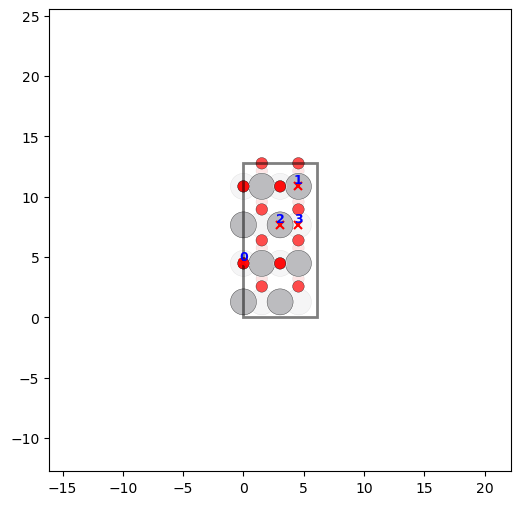

获取到的位点类型有: ['ontop', 'bridge', 'hollow']
Loaded molecule from periodic structure file: CONTCAR
Start generating structures for CONTCAR...
Successfully generated 1 structures.
Saved 1 structures to /data2/home/luodh/Test/VaspStructure-Test/ads
✅ 链式调用测试完成，文件保存在: /data2/home/luodh/Test/VaspStructure-Test/ads


In [21]:
import sys
from pathlib import Path

# 1. 路径与环境配置
actual_path = "/data2/home/luodh/Git-workflow/Workflow_for_vasp_catalysis"

if actual_path not in sys.path:
    sys.path.insert(0, actual_path)

print("Current sys.path:", sys.path[0])

from vasp_catalysis_tools.core.adsorption import AdsorptionModify

slab_source = Path("/data2/home/luodh/Test/VaspStructure-Test/POSCAR_110_10L_auto").resolve()
output_path = Path("/data2/home/luodh/Test/VaspStructure-Test/ads").resolve()

modifier1 = AdsorptionModify(slab_source=slab_source, save_dir=output_path)

sites_dict = modifier1.analyze(plot=True)  # 查找位点 (设为 True 可以看图)
print(f"获取到的位点类型有: {list(sites_dict.keys())}")

mol_source = Path("/data2/home/luodh/Molecular/C3H6/CONTCAR").resolve() #可以直接传入周期性结构的分子或者分子式（从ase中传入）
(
    modifier1
    .generate(molecule_formula=str(mol_source), 
              find_args={"positions": ["ontop"]}, #只在ontop上
              plot=False) # 不设定find_args默认在所有位点吸附 CO (返回 self)
    .save_all(as_subdirs=False)  # 以子文件夹形式保存 (返回 None)
)
print(f"✅ 链式调用测试完成，文件保存在: {output_path}")


Initialized AdsorptionModify with slab from: /data2/home/luodh/Test/VaspStructure-Test/POSCAR_110_10L_auto
Running in mode: generate
Start generating structures for CH3...
Successfully generated 4 structures.


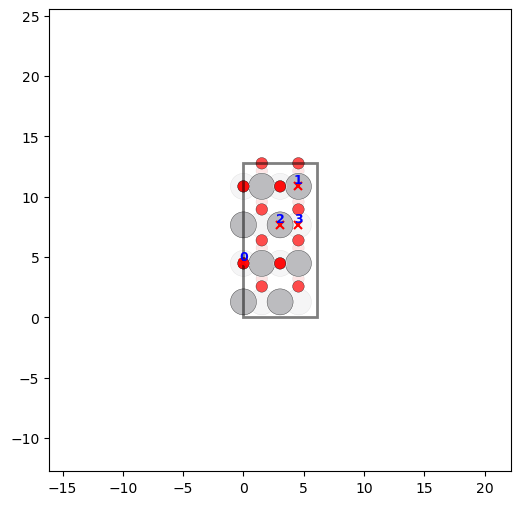

Saved 4 structures to /data2/home/luodh/Test/VaspStructure-Test/ads
✅ 字典驱动测试完成，共生成 4 个结构，保存在: /data2/home/luodh/Test/VaspStructure-Test/ads


In [22]:
#str之后直接传入也可
# mol_source = Path("/data2/home/luodh/Molecular/C3H6/CONTCAR").resolve() #可以直接传入周期性结构的分子或者分子式（从ase中传入）

config = {
    "target_slab_source": slab_source,
    "save_dir": output_path,
    "mode": "generate",
    "generate_params": {
        "molecule_formula": "CH3", # 自动从 ASE 库获取 OH 分子
        "find_args": {
            "positions": ["ontop", "bridge"],# 过滤：只在这两种位点吸附
            "distance":1.0,  #设置吸附位置
        }
    },
    "save_options": {
        "save": True,
        "as_subdirs": True, # 不建子文件夹，直接命名为 POSCAR_ontop_0 等
        "filename": "POSCAR"
    },
    "plot": True
}

generated_structs = AdsorptionModify.run_from_dict(config)
print(f"✅ 字典驱动测试完成，共生成 {len(generated_structs)} 个结构，保存在: {output_path}")

In [23]:
relative_structure = Path("/data2/home/luodh/Test/VaspStructure-Test/ads/CONTCAR").resolve()
config_relative = {
    "target_slab_source": slab_source,
    "save_dir": output_path,
    "mode": "relative",
    "relative_params":{
        "reference_slab_source": relative_structure,
        "adsorbate_indices": list(range(56,66)),
        "adsorbate_anchor_indices": [35],
        "find_args":{
            "positions":["ontop"],
            "distance":1.0,}
        },
    "save_options": {
        "save": True,
        "as_subdirs": True,
        "filename": "POSCAR"
    }
}
AdsorptionModify.run_from_dict(config_relative)
print(f"✅ 字典驱动 Relative 测试完成，文件保存在: {output_path}")

Initialized AdsorptionModify with slab from: /data2/home/luodh/Test/VaspStructure-Test/POSCAR_110_10L_auto
Running in mode: relative
提示: 在 relative 模式下，'distance' 参数已被忽略。分子高度将 100% 继承自参考结构。
Start placing relative adsorbate...
Successfully placed relative adsorbate on 1 sites.
Saved 1 structures to /data2/home/luodh/Test/VaspStructure-Test/ads
✅ 字典驱动 Relative 测试完成，文件保存在: /data2/home/luodh/Test/VaspStructure-Test/ads


In [24]:
modifier_rel = AdsorptionModify(slab_source=slab_source, save_dir=output_path)

(
    modifier_rel
    .place_relative(
        reference_slab_source=relative_structure,
        adsorbate_indices=list(range(56,66)),
        adsorbate_anchor_indices=[35],
        find_args={"positions":["ontop"]}
    )
    .save_all(as_subdirs=True)
)


Initialized AdsorptionModify with slab from: /data2/home/luodh/Test/VaspStructure-Test/POSCAR_110_10L_auto
Start placing relative adsorbate...
Successfully placed relative adsorbate on 1 sites.
Saved 1 structures to /data2/home/luodh/Test/VaspStructure-Test/ads


### Particle结构的使用方法
实现了多种方法，包括wulff结构，球形结构，纳米棒结构

In [3]:
import sys
from pathlib import Path

# 1. 路径与环境配置
actual_path = "/data2/home/luodh/Git-workflow/Workflow_for_vasp_catalysis"

if actual_path not in sys.path:
    sys.path.insert(0, actual_path)

print("Current sys.path:", sys.path[0])

from vasp_catalysis_tools.core.Particle import ParticleGenerator

output_path = Path("/data2/home/luodh/Test/VaspStructure-Test/particle").resolve()
## Wulff结构的生成方法
ParticleGenerator("Au").wulff(
    surface_energies={"111": 0.8, "100": 1.0, "110": 1.2},
    size=10.0,
    vacuum=8.0,
).save_all(filename= output_path / "Au-POSCAR", fmt="poscar")

ParticleGenerator.run_from_dict({
    "element": "Au", "mode": "wulff",
    "wulff_params": {
        "surface_energies": {"111": 0.8, "100": 1.0},
        "size": 25.0,
        "vacuum": 12.0   
    }
})

Current sys.path: /data2/home/luodh/Git-workflow/Workflow_for_vasp_catalysis
Initialized ParticleGenerator: Au, a=4.078 Å, type=fcc
Wulff shape built. Anisotropy: 0.0858, Weighted surface energy: 0.8298 J/m²
Area fractions: {'(1, 1, 1)': 0.851, '(1, 0, 0)': 0.149, '(1, 1, 0)': 0.0}
Generated Wulff particle: 459 atoms, vacuum=8.0 Å/side, label='wulff_n459'
  Saved: /data2/home/luodh/Test/VaspStructure-Test/particle/Au-POSCAR
Saved 1 structure(s).


In [2]:
"""
ParticleGenerator 完整使用示例
涵盖所有方法及其参数，每个示例均保存结构以便可视化验证。
"""
import sys
from pathlib import Path

# 1. 路径与环境配置
actual_path = "/data2/home/luodh/Git-workflow/Workflow_for_vasp_catalysis"

if actual_path not in sys.path:
    sys.path.insert(0, actual_path)

print("Current sys.path:", sys.path[0])

from vasp_catalysis_tools.core.Particle import ParticleGenerator

# 统一输出根目录
ROOT = Path("/data2/home/luodh/Test/VaspStructure-Test/particle").resolve()

# ==============================================================================
# 1. 初始化方式
# ==============================================================================
print("\n" + "=" * 60)
print("1. 初始化方式")
print("=" * 60)

# 1-1. 最简初始化（自动查表晶格常数）
gen1 = ParticleGenerator("Au")

# 1-2. 手动指定晶格常数
gen2 = ParticleGenerator("Au", lattice_constant=4.078)

# 1-3. BCC 晶格
gen3 = ParticleGenerator("Fe", lattice_constant=2.867, lattice_type="bcc")

# 1-4. HCP 晶格
gen4 = ParticleGenerator("Ti", lattice_constant=2.951, lattice_type="hcp")

# 1-5. 指定默认输出目录
gen5 = ParticleGenerator("Pt", save_dir=ROOT / "pt_init")

# 1-6. 完整参数
gen6 = ParticleGenerator(
    element="Pd",
    lattice_constant=3.891,
    lattice_type="fcc",
    save_dir=ROOT / "pd_init",
)


# ==============================================================================
# 2. wulff() —— Wulff 平衡形状
# ==============================================================================
print("\n" + "=" * 60)
print("2. wulff() —— Wulff 平衡形状")
print("=" * 60)

# 2-1. 最简调用：字符串键，默认 size=30 Å，默认 vacuum=15 Å
ParticleGenerator("Au", save_dir=ROOT / "wulff" / "2-1_default").wulff(
    surface_energies={"111": 0.8, "100": 1.0, "110": 1.2},
).save_all(filename="POSCAR")

# 2-2. 指定粒子尺寸
ParticleGenerator("Au", save_dir=ROOT / "wulff" / "2-2_size").wulff(
    surface_energies={"111": 0.8, "100": 1.0, "110": 1.2},
    size=25.0,
).save_all(filename="POSCAR")

# 2-3. 指定真空层（紧凑盒子）
ParticleGenerator("Au", save_dir=ROOT / "wulff" / "2-3_vacuum10").wulff(
    surface_energies={"111": 0.8, "100": 1.0, "110": 1.2},
    size=25.0,
    vacuum=10.0,
).save_all(filename="POSCAR")

# 2-4. 指定真空层（超大真空，避免镜像相互作用）
ParticleGenerator("Au", save_dir=ROOT / "wulff" / "2-4_vacuum20").wulff(
    surface_energies={"111": 0.8, "100": 1.0, "110": 1.2},
    size=25.0,
    vacuum=20.0,
).save_all(filename="POSCAR")

# 2-5. 元组键
ParticleGenerator("Pt", save_dir=ROOT / "wulff" / "2-5_tuple_key").wulff(
    surface_energies={(1, 1, 1): 0.9, (1, 0, 0): 1.1, (1, 1, 0): 1.3},
    size=30.0,
    vacuum=15.0,
).save_all(filename="POSCAR")

# 2-6. 逗号分隔字符串键
ParticleGenerator("Pd", save_dir=ROOT / "wulff" / "2-6_comma_key").wulff(
    surface_energies={"1,1,1": 0.75, "1,0,0": 0.95, "1,1,0": 1.1},
    size=20.0,
    vacuum=15.0,
).save_all(filename="POSCAR")

# 2-7. 只有两个晶面（接近球形）
ParticleGenerator("Ni", save_dir=ROOT / "wulff" / "2-7_two_facets").wulff(
    surface_energies={"111": 1.0, "100": 1.0},
    size=15.0,
    vacuum=15.0,
).save_all(filename="POSCAR")

# 2-8. 各向异性强（表面能差异大）
ParticleGenerator("Au", save_dir=ROOT / "wulff" / "2-8_anisotropic").wulff(
    surface_energies={"111": 0.5, "100": 1.5, "110": 2.0},
    size=25.0,
    vacuum=15.0,
).save_all(filename="POSCAR")

# 2-9. 保存到完整绝对路径
ParticleGenerator("Au").wulff(
    surface_energies={"111": 0.8, "100": 1.0},
    size=20.0,
    vacuum=15.0,
).save_all(filename=ROOT / "wulff" / "2-9_abspath" / "POSCAR")

# 2-10. 同时导出 CIF（便于 VESTA 可视化）
ParticleGenerator("Au", save_dir=ROOT / "wulff" / "2-10_cif").wulff(
    surface_energies={"111": 0.8, "100": 1.0, "110": 1.2},
    size=25.0,
    vacuum=15.0,
).save_all(filename="structure.cif", fmt="cif")


# ==============================================================================
# 3. sphere() —— 球形纳米粒子
# ==============================================================================
print("\n" + "=" * 60)
print("3. sphere() —— 球形纳米粒子")
print("=" * 60)

# 3-1. 最简调用
ParticleGenerator("Au", save_dir=ROOT / "sphere" / "3-1_default").sphere(
    radius=15.0,
).save_all(filename="POSCAR")

# 3-2. 小尺寸
ParticleGenerator("Cu", save_dir=ROOT / "sphere" / "3-2_small").sphere(
    radius=8.0,
).save_all(filename="POSCAR")

# 3-3. 指定真空层
ParticleGenerator("Ag", save_dir=ROOT / "sphere" / "3-3_vacuum").sphere(
    radius=12.0,
    vacuum=10.0,
).save_all(filename="POSCAR")

# 3-4. BCC 球形粒子
ParticleGenerator("Fe", lattice_type="bcc",
                  save_dir=ROOT / "sphere" / "3-4_bcc").sphere(
    radius=12.0,
    vacuum=15.0,
).save_all(filename="POSCAR")

# 3-5. 保存到完整路径 + CIF
ParticleGenerator("Pt").sphere(radius=10.0, vacuum=15.0).save_all(
    filename=ROOT / "sphere" / "3-5_abspath" / "POSCAR",
)
ParticleGenerator("Pt", save_dir=ROOT / "sphere" / "3-5_cif").sphere(
    radius=10.0, vacuum=15.0,
).save_all(filename="structure.cif", fmt="cif")


# ==============================================================================
# 4. octahedron() —— 八面体 / 截角八面体（ASE）
# ==============================================================================
print("\n" + "=" * 60)
print("4. octahedron() —— 八面体 / 截角八面体（ASE）")
print("=" * 60)

# 4-1. 完整八面体（cutoff=0）
ParticleGenerator("Pt", save_dir=ROOT / "octahedron" / "4-1_full").octahedron(
    layers=[5],
    vacuum=15.0,
).save_all(filename="POSCAR")

# 4-2. 截角八面体（cutoff=2）
ParticleGenerator("Pt", save_dir=ROOT / "octahedron" / "4-2_truncated").octahedron(
    layers=[5, 2],
    vacuum=15.0,
).save_all(filename="POSCAR")

# 4-3. 更大截断
ParticleGenerator("Au", save_dir=ROOT / "octahedron" / "4-3_large_cut").octahedron(
    layers=[7, 3],
    vacuum=15.0,
).save_all(filename="POSCAR")

# 4-4. 手动晶格常数 + 自定义真空
ParticleGenerator("Pd", save_dir=ROOT / "octahedron" / "4-4_custom").octahedron(
    layers=[6, 2],
    latticeconstant=3.891,
    vacuum=12.0,
).save_all(filename="POSCAR")

# 4-5. 保存到完整路径
ParticleGenerator("Pt").octahedron(layers=[5, 2], vacuum=15.0).save_all(
    filename=ROOT / "octahedron" / "4-5_abspath" / "POSCAR",
)


# ==============================================================================
# 5. decahedron() —— 十面体（ASE Ino decahedron）
# ==============================================================================
print("\n" + "=" * 60)
print("5. decahedron() —— 十面体（ASE）")
print("=" * 60)

# 5-1. 标准 Ino 十面体（r=0）
ParticleGenerator("Au", save_dir=ROOT / "decahedron" / "5-1_standard").decahedron(
    p=3, q=2, r=0,
    vacuum=15.0,
).save_all(filename="POSCAR")

# 5-2. 带腰部重构（r=1）
ParticleGenerator("Au", save_dir=ROOT / "decahedron" / "5-2_recon").decahedron(
    p=4, q=2, r=1,
    vacuum=15.0,
).save_all(filename="POSCAR")

# 5-3. 较大尺寸
ParticleGenerator("Ag", save_dir=ROOT / "decahedron" / "5-3_large").decahedron(
    p=5, q=3, r=0,
    vacuum=15.0,
).save_all(filename="POSCAR")

# 5-4. 手动晶格常数 + 自定义真空
ParticleGenerator("Pt", save_dir=ROOT / "decahedron" / "5-4_custom").decahedron(
    p=3, q=2, r=0,
    latticeconstant=3.924,
    vacuum=12.0,
).save_all(filename="POSCAR")

# 5-5. 保存到完整路径
ParticleGenerator("Au").decahedron(p=4, q=2, r=1, vacuum=15.0).save_all(
    filename=ROOT / "decahedron" / "5-5_abspath" / "POSCAR",
)


# ==============================================================================
# 6. icosahedron() —— 二十面体（ASE Mackay icosahedron）
# ==============================================================================
print("\n" + "=" * 60)
print("6. icosahedron() —— 二十面体（ASE）")
print("=" * 60)

# 6-1. 1 壳层（13 原子）
ParticleGenerator("Au", save_dir=ROOT / "icosahedron" / "6-1_n1").icosahedron(
    n_shells=1,
    vacuum=15.0,
).save_all(filename="POSCAR")

# 6-2. 2 壳层（55 原子）
ParticleGenerator("Au", save_dir=ROOT / "icosahedron" / "6-2_n2").icosahedron(
    n_shells=2,
    vacuum=15.0,
).save_all(filename="POSCAR")

# 6-3. 3 壳层（147 原子）
ParticleGenerator("Pt", save_dir=ROOT / "icosahedron" / "6-3_n3").icosahedron(
    n_shells=3,
    vacuum=15.0,
).save_all(filename="POSCAR")

# 6-4. 4 壳层（309 原子）
ParticleGenerator("Ni", save_dir=ROOT / "icosahedron" / "6-4_n4").icosahedron(
    n_shells=4,
    vacuum=15.0,
).save_all(filename="POSCAR")

# 6-5. 手动最近邻距离 + 自定义真空
ParticleGenerator("Au", save_dir=ROOT / "icosahedron" / "6-5_custom").icosahedron(
    n_shells=3,
    latticeconstant=2.884,   # Au FCC 最近邻: 4.078 / √2 ≈ 2.884 Å
    vacuum=12.0,
).save_all(filename="POSCAR")

# 6-6. 保存到完整路径
ParticleGenerator("Au").icosahedron(n_shells=3, vacuum=15.0).save_all(
    filename=ROOT / "icosahedron" / "6-6_abspath" / "POSCAR",
)


# ==============================================================================
# 7. fcc_cube() —— FCC 任意晶面截断粒子（ASE FaceCenteredCubic）
# ==============================================================================
print("\n" + "=" * 60)
print("7. fcc_cube() —— FCC 任意晶面截断粒子（ASE）")
print("=" * 60)

# 7-1. 两晶面截断（(100)+(111)）
ParticleGenerator("Au", save_dir=ROOT / "fcc_cube" / "7-1_two_facets").fcc_cube(
    surfaces=[[1, 0, 0], [1, 1, 1]],
    layers=[4, 6],
    vacuum=15.0,
).save_all(filename="POSCAR")

# 7-2. 三晶面截断（截角八面体近似）
ParticleGenerator("Pt", save_dir=ROOT / "fcc_cube" / "7-2_three_facets").fcc_cube(
    surfaces=[[1, 0, 0], [1, 1, 0], [1, 1, 1]],
    layers=[6, 4, 8],
    vacuum=15.0,
).save_all(filename="POSCAR")

# 7-3. 手动晶格常数 + 自定义真空
ParticleGenerator("Cu", save_dir=ROOT / "fcc_cube" / "7-3_custom").fcc_cube(
    surfaces=[[1, 0, 0], [1, 1, 1]],
    layers=[5, 7],
    latticeconstant=3.615,
    vacuum=12.0,
).save_all(filename="POSCAR")

# 7-4. 保存到完整路径
ParticleGenerator("Au").fcc_cube(
    surfaces=[[1, 0, 0], [1, 1, 0], [1, 1, 1]],
    layers=[6, 4, 8],
    vacuum=15.0,
).save_all(filename=ROOT / "fcc_cube" / "7-4_abspath" / "POSCAR")


# ==============================================================================
# 8. rod() —— 纳米棒
# ==============================================================================
print("\n" + "=" * 60)
print("8. rod() —— 纳米棒")
print("=" * 60)

# 8-1. 标准纳米棒
ParticleGenerator("Au", save_dir=ROOT / "rod" / "8-1_standard").rod(
    radius=8.0, length=30.0,
    vacuum=15.0,
).save_all(filename="POSCAR")

# 8-2. 细长纳米棒
ParticleGenerator("Cu", save_dir=ROOT / "rod" / "8-2_thin").rod(
    radius=5.0, length=50.0,
    vacuum=15.0,
).save_all(filename="POSCAR")

# 8-3. 粗短纳米棒（接近圆柱体）
ParticleGenerator("Pt", save_dir=ROOT / "rod" / "8-3_thick").rod(
    radius=12.0, length=20.0,
    vacuum=15.0,
).save_all(filename="POSCAR")

# 8-4. 自定义真空
ParticleGenerator("Au", save_dir=ROOT / "rod" / "8-4_vacuum").rod(
    radius=8.0, length=30.0,
    vacuum=10.0,
).save_all(filename="POSCAR")

# 8-5. BCC 纳米棒
ParticleGenerator("Fe", lattice_type="bcc",
                  save_dir=ROOT / "rod" / "8-5_bcc").rod(
    radius=8.0, length=25.0,
    vacuum=15.0,
).save_all(filename="POSCAR")

# 8-6. 保存到完整路径
ParticleGenerator("Au").rod(radius=8.0, length=30.0, vacuum=15.0).save_all(
    filename=ROOT / "rod" / "8-6_abspath" / "POSCAR",
)


# ==============================================================================
# 9. save_all() —— 所有保存方式
# ==============================================================================
print("\n" + "=" * 60)
print("9. save_all() —— 所有保存方式")
print("=" * 60)

_base = ParticleGenerator("Au").wulff({"111": 0.8, "100": 1.0}, size=20.0, vacuum=15.0)

# 9-1. 默认（文件名 POSCAR，保存到 self.save_dir）
_base.save_all()

# 9-2. 自定义文件名
_base.save_all(filename="CONTCAR")

# 9-3. 完整绝对路径（单结构直接写入）
_base.save_all(filename=ROOT / "save_all" / "9-3_abspath" / "POSCAR")

# 9-4. 文件名 + 临时 save_dir（不修改 self.save_dir）
_base.save_all(filename="POSCAR", save_dir=ROOT / "save_all" / "9-4_tmpdir")

# 9-5. 不建子目录
_base.save_all(filename="POSCAR", as_subdirs=False,
               save_dir=ROOT / "save_all" / "9-5_no_subdirs")

# 9-6. CIF 格式（VESTA 可直接打开）
_base.save_all(filename="structure.cif", fmt="cif",
               save_dir=ROOT / "save_all" / "9-6_cif")

# 9-7. 完整参数
_base.save_all(
    filename="POSCAR",
    fmt="poscar",
    as_subdirs=True,
    save_dir=ROOT / "save_all" / "9-7_full",
)


# ==============================================================================
# 10. to_xyz() —— 导出 XYZ（ASE / OVITO 可视化）
# ==============================================================================
print("\n" + "=" * 60)
print("10. to_xyz() —— 导出 XYZ 格式")
print("=" * 60)

_gen_xyz = ParticleGenerator("Au").sphere(radius=10.0, vacuum=15.0)

# 10-1. 仅返回字符串
xyz_str = _gen_xyz.to_xyz()
print("XYZ 前 3 行:")
for line in xyz_str.split("\n")[:3]:
    print(f"  {line}")

# 10-2. 写入文件
_gen_xyz.to_xyz(filename=ROOT / "xyz" / "Au_sphere.xyz")

# 10-3. 指定结构索引
_gen_xyz.to_xyz(index=0, filename=ROOT / "xyz" / "Au_sphere_idx0.xyz")

# 10-4. 最后一个结构（默认 index=-1）
_gen_xyz.to_xyz(index=-1, filename=ROOT / "xyz" / "Au_sphere_last.xyz")


# ==============================================================================
# 11. get_structure() / get_structures() —— 获取结构对象后处理
# ==============================================================================
print("\n" + "=" * 60)
print("11. 获取结构对象")
print("=" * 60)

_gen_get = ParticleGenerator("Au").wulff({"111": 0.8, "100": 1.0}, size=20.0, vacuum=15.0)

# 11-1. 获取最后一个（默认）
s = _gen_get.get_structure()
print(f"最后一个结构: {s.formula}, {len(s)} 原子")
print(f"晶格: a={s.lattice.a:.2f}, b={s.lattice.b:.2f}, c={s.lattice.c:.2f} Å")

# 11-2. 指定索引
s0 = _gen_get.get_structure(index=0)
print(f"第 0 个结构: {s0.formula}")

# 11-3. 获取全部列表
all_s = _gen_get.get_structures()
print(f"共 {len(all_s)} 个结构")

# 11-4. 获取后用 pymatgen 进一步分析
from pymatgen.io.vasp import Poscar
poscar = Poscar(_gen_get.get_structure())
(ROOT / "get_structure").mkdir(parents=True, exist_ok=True)
with open(ROOT / "get_structure" / "POSCAR_manual", "wt") as f:
    f.write(poscar.get_string())
print("手动写入 POSCAR_manual 完成")


# ==============================================================================
# 12. run_from_dict() —— 配置驱动（AI 平台推荐方式）
# ==============================================================================
print("\n" + "=" * 60)
print("12. run_from_dict() —— 配置驱动")
print("=" * 60)

# 12-1. Wulff 模式（含 vacuum）
ParticleGenerator.run_from_dict({
    "element": "Au",
    "lattice_constant": 4.078,
    "lattice_type": "fcc",
    "save_dir": str(ROOT / "run_from_dict" / "12-1_wulff"),
    "mode": "wulff",
    "wulff_params": {
        "surface_energies": {"111": 0.8, "100": 1.0, "110": 1.2},
        "size": 25.0,
        "vacuum": 15.0,
    },
    "save_options": {"save": True, "filename": "POSCAR", "fmt": "poscar"},
})

# 12-2. Wulff 模式（紧凑真空）
ParticleGenerator.run_from_dict({
    "element": "Pt",
    "save_dir": str(ROOT / "run_from_dict" / "12-2_wulff_compact"),
    "mode": "wulff",
    "wulff_params": {
        "surface_energies": {"111": 0.9, "100": 1.1},
        "size": 20.0,
        "vacuum": 10.0,
    },
    "save_options": {"save": True, "filename": "POSCAR"},
})

# 12-3. 球形模式
ParticleGenerator.run_from_dict({
    "element": "Ag",
    "save_dir": str(ROOT / "run_from_dict" / "12-3_sphere"),
    "mode": "sphere",
    "sphere_params": {"radius": 15.0, "vacuum": 15.0},
    "save_options": {"save": True, "filename": "POSCAR"},
})

# 12-4. 八面体模式
ParticleGenerator.run_from_dict({
    "element": "Pt",
    "lattice_constant": 3.924,
    "save_dir": str(ROOT / "run_from_dict" / "12-4_octahedron"),
    "mode": "octahedron",
    "octahedron_params": {"layers": [5, 2], "latticeconstant": 3.924, "vacuum": 15.0},
    "save_options": {"save": True, "filename": "POSCAR"},
})

# 12-5. 十面体模式
ParticleGenerator.run_from_dict({
    "element": "Au",
    "save_dir": str(ROOT / "run_from_dict" / "12-5_decahedron"),
    "mode": "decahedron",
    "decahedron_params": {"p": 4, "q": 2, "r": 1, "vacuum": 15.0},
    "save_options": {"save": True, "filename": "POSCAR"},
})

# 12-6. 二十面体模式
ParticleGenerator.run_from_dict({
    "element": "Au",
    "save_dir": str(ROOT / "run_from_dict" / "12-6_icosahedron"),
    "mode": "icosahedron",
    "icosahedron_params": {"n_shells": 3, "vacuum": 15.0},
    "save_options": {"save": True, "filename": "POSCAR"},
})

# 12-7. FCC 立方体模式
ParticleGenerator.run_from_dict({
    "element": "Cu",
    "lattice_type": "fcc",
    "save_dir": str(ROOT / "run_from_dict" / "12-7_fcc_cube"),
    "mode": "fcc_cube",
    "fcc_cube_params": {
        "surfaces": [[1, 0, 0], [1, 1, 0], [1, 1, 1]],
        "layers": [6, 4, 8],
        "latticeconstant": 3.615,
        "vacuum": 15.0,
    },
    "save_options": {"save": True, "filename": "POSCAR"},
})

# 12-8. 纳米棒模式
ParticleGenerator.run_from_dict({
    "element": "Au",
    "save_dir": str(ROOT / "run_from_dict" / "12-8_rod"),
    "mode": "rod",
    "rod_params": {"radius": 8.0, "length": 30.0, "vacuum": 15.0},
    "save_options": {"save": True, "filename": "POSCAR", "fmt": "poscar"},
})

# 12-9. 不保存，仅返回结构列表
structs = ParticleGenerator.run_from_dict({
    "element": "Ni",
    "mode": "sphere",
    "sphere_params": {"radius": 10.0, "vacuum": 15.0},
    "save_options": {"save": False},
})
print(f"返回结构数: {len(structs)}, 原子数: {len(structs[0])}")


# ==============================================================================
# 13. 链式调用综合示例
# ==============================================================================
print("\n" + "=" * 60)
print("13. 链式调用综合示例")
print("=" * 60)

# 13-1. Wulff → 保存 POSCAR + CIF（双格式，便于不同软件可视化）
gen_dual = ParticleGenerator("Au", save_dir=ROOT / "chain" / "13-1_dual_fmt")
gen_dual.wulff({"111": 0.8, "100": 1.0, "110": 1.2}, size=25.0, vacuum=15.0)
gen_dual.save_all(filename="POSCAR", fmt="poscar")
gen_dual.save_all(filename="structure.cif", fmt="cif")

# 13-2. 生成 → 获取结构 → pymatgen 后处理
struct = (
    ParticleGenerator("Pt", lattice_constant=3.924)
    .octahedron(layers=[6, 2], vacuum=15.0)
    .get_structure()
)
print(f"Pt 截角八面体: {struct.formula}, {len(struct)} 原子")

# 13-3. 生成 → XYZ（OVITO 可视化）
(
    ParticleGenerator("Au")
    .icosahedron(n_shells=3, vacuum=15.0)
    .to_xyz(filename=ROOT / "chain" / "Au_ico_n3.xyz")
)

# 13-4. 不同真空层对比（同一粒子，验证盒子尺寸影响）
for vac in [8.0, 12.0, 15.0, 20.0]:
    ParticleGenerator("Au",
                      save_dir=ROOT / "chain" / "13-4_vacuum_compare" / f"vac{vac:.0f}").wulff(
        surface_energies={"111": 0.8, "100": 1.0},
        size=20.0,
        vacuum=vac,
    ).save_all(filename="POSCAR")

# 13-5. 不同尺寸对比（同一 Wulff 形状，验证原子数随 size 变化）
for sz in [15.0, 20.0, 25.0, 30.0]:
    ParticleGenerator("Au",
                      save_dir=ROOT / "chain" / "13-5_size_compare" / f"size{sz:.0f}").wulff(
        surface_energies={"111": 0.8, "100": 1.0, "110": 1.2},
        size=sz,
        vacuum=15.0,
    ).save_all(filename="POSCAR")

print(f"\n所有结构已保存至: {ROOT}")
print("推荐使用 VESTA（CIF/POSCAR）或 OVITO（XYZ）进行可视化验证。")

Current sys.path: /data2/home/luodh/Git-workflow/Workflow_for_vasp_catalysis

1. 初始化方式
Initialized ParticleGenerator: Au, a=4.078 Å, type=fcc
Initialized ParticleGenerator: Au, a=4.078 Å, type=fcc
Initialized ParticleGenerator: Fe, a=2.867 Å, type=bcc
Initialized ParticleGenerator: Ti, a=2.951 Å, type=hcp
Initialized ParticleGenerator: Pt, a=3.924 Å, type=fcc
Initialized ParticleGenerator: Pd, a=3.891 Å, type=fcc

2. wulff() —— Wulff 平衡形状
Initialized ParticleGenerator: Au, a=4.078 Å, type=fcc
Wulff shape built. Anisotropy: 0.0858, Weighted surface energy: 0.8298 J/m²
Area fractions: {'(1, 1, 1)': 0.851, '(1, 0, 0)': 0.149, '(1, 1, 0)': 0.0}
Generated Wulff particle: 9879 atoms, vacuum=15.0 Å/side, label='wulff_n9879'
  Saved: /data2/home/luodh/Test/VaspStructure-Test/particle/wulff/2-1_default/POSCAR
Saved 1 structure(s).
Initialized ParticleGenerator: Au, a=4.078 Å, type=fcc
Wulff shape built. Anisotropy: 0.0858, Weighted surface energy: 0.8298 J/m²
Area fractions: {'(1, 1, 1)': 0.851